# Milestone 3: Complete Implementation
**Project:** Data Mining Project (CS 4412)  
**Context:** This notebook implements the preprocessing, exploratory data analysis (EDA), and preliminary association rule mining for the Goodreads 2017 dataset.

**Dataset:** [Goodreads Dataset Source](https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html)

### Core Objectives
1. **Genre Association Discovery:** Identify hidden relationships between user-defined "shelves" using FP-Growth.
2. **Engagement Analysis:** Quantify the relationship between ratings, review length, and social interaction (votes/comments).
3. **Data Refinement:** Clean and filter the 2.36M book metadata records and 15.7M reviews into a high-quality "Romantasy" and Romance subset.

# Section 1: Preprocessing and Data Transformation
The raw Goodreads dataset is multi-gigabyte and contains significant noise. We implement a two-stage filtering pipeline:

1. **Language Filtering:** Using the `pycld2` package to ensure a monolingual English dataset.
2. **Genre Targeting:** Extracting records associated with 'Romantasy' and related sub-genres.
3. **Tag Cleaning:** Removing administrative tags (e.g., 'to-read', 'owned', 'kindle') that skew frequency distributions without providing categorical value.

In [1]:
import json
import gzip
import os
import pycld2 as cld2

def is_english(text):
    if not text or len(text.strip()) < 10:
        return False
    try:
        # details[0][1] returns the ISO language code (e.g., 'en')
        is_reliable, _, details = cld2.detect(text)
        return details[0][1] == 'en'
    except Exception:
        return False

def filter_english(input_path, output_path):
    """
    Filters a JSON/JSON.GZ file for English records.
    """
    print(f"Reading from: {input_path}")
    print(f"Writing to:   {output_path}")
    
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    
    count = 0
    saved = 0
    open_func = gzip.open if input_path.endswith('.gz') else open

    with open_func(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        for line in fin:
            try:
                record = json.loads(line)
                count += 1
                
                # Check review text first, fallback to title
                texts_to_check = record.get('review_text', record.get('title', ''))

                if is_english(texts_to_check):
                    fout.write(line)
                    saved += 1
                
                if count % 50000 == 0:
                    print(f"Processed {count}... Saved {saved} English records")
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Processed {count} total. Saved {saved} English records.")

# --- How to call it in your notebook ---
RAW_DATA = '../data/goodreads_reviews_dedup.json.gz'
CLEAN_DATA = '../data/goodreads_reviews_english.json'

if os.path.exists(RAW_DATA):
    filter_english(RAW_DATA, CLEAN_DATA)
else:
    print(f"File not found: {RAW_DATA}")

Reading from: ../data/goodreads_reviews_dedup.json.gz
Writing to:   ../data/goodreads_reviews_english.json
Processed 50000... Saved 45302 English records
Processed 100000... Saved 91916 English records
Processed 150000... Saved 137916 English records
Processed 200000... Saved 183852 English records
Processed 250000... Saved 228386 English records
Processed 300000... Saved 273960 English records
Processed 350000... Saved 320313 English records
Processed 400000... Saved 364625 English records
Processed 450000... Saved 410819 English records
Processed 500000... Saved 454098 English records
Processed 550000... Saved 499181 English records
Processed 600000... Saved 545274 English records
Processed 650000... Saved 589492 English records
Processed 700000... Saved 635555 English records
Processed 750000... Saved 680098 English records
Processed 800000... Saved 723922 English records
Processed 850000... Saved 768578 English records
Processed 900000... Saved 814068 English records
Processed 9500

1. Create 01_filteredbooks.json and filter out books in the dataset that match Romantasy genres

In [2]:
import json
import os
import pandas as pd

# --- Configuration ---
INPUT_FILTERED_JSON = '../data/01_filteredbooks.json'
CLEAN_NOADMIN_JSON = '../data/01_filteredbooks_noadmin.json'
OUTPUT_BOOKS_CSV = '../data/02_extractedbooks.csv'

# Parameters
MIN_SHELF_COUNT = 10

def clean_admin_tags(input_path, output_path, min_count=10):
    """
    Filters out 'administrative' tags (like 'to-read' or 'kindle') from book shelves.
    """
    print(f"Cleaning tags: {input_path} -> {output_path}")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    book_count = 0
    generic_tags = {
        'to-read', 'currently-reading', 'owned', 'favorites', 'all-time-favorites', 
        'books-i-own', 'read-in-2017', 'read-in-2016', 'default', 'ebook', 'kindle', 
        'audiobook', 'my-books', 'library', 'wish-list', 'maybe', 'finish', 'read',
        'to-own', 'i-own', 'on-my-shelf', 'dnf', 'my-personal-library', 're-read', 
        'tbr', 'tbr-pile', 'to read', 'currently reading', 'owned', 'favorites', 
        'all time favorites', 'books i own', 'audiobooks', 'my books', 'wish list', 
        'e book', 'hardcover', 'paperback', 'hardback', 'shelfari favorites', 
        'owned books', 'favorite', 'paper', 'hardcopy', 'unfinished', 'duplicates',
        'i own it', 'not read', 'read some day', 'own hard copy', 'in my home library',
        'to-buy', 'audio', 'my library', 'to buy', 'ebooks'
    }

    with open(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:

        for line in fin:
            try:
                book = json.loads(line)
                raw_shelves = book.get('popular_shelves', [])
                filtered_shelves = []

                for s in raw_shelves:
                    # Handle both dict and string formats in popular_shelves
                    try:
                        count = int(s.get('count', 0)) if isinstance(s, dict) else 0
                        name = s.get('name', '').strip() if isinstance(s, dict) else str(s).strip()
                    except (ValueError, TypeError, AttributeError):
                        continue

                    if count < min_count and isinstance(s, dict):
                        continue

                    if not name:
                        continue

                    # Normalization for filtering
                    norm = name.lower().replace('-', ' ').replace('_', ' ').strip()
                    
                    if (norm.startswith('read in') or 
                        norm in generic_tags or 
                        len(norm) <= 2 or 
                        norm.isdigit()):
                        continue

                    filtered_shelves.append(name.replace(',', ' ').strip())

                # Only save books that still have meaningful tags left
                if len(filtered_shelves) > 1:
                    book['popular_shelves'] = filtered_shelves
                    fout.write(json.dumps(book) + '\n')
                    book_count += 1

                if book_count % 50000 == 0 and book_count > 0:
                    print(f"Cleaned {book_count} books...")
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Saved {book_count} clean books to {output_path}.")

def flatten_shelves(shelves_list):
    if not isinstance(shelves_list, list):
        return ""
    return ", ".join(shelves_list[:10])

def make_books_table(input_json, output_csv):
    """
    Converts the cleaned JSON into a flat CSV for easier EDA.
    """
    print(f"Formatting {input_json} to CSV...")
    try:
        # Using a sample or chunked read is safer for memory
        # If the file is small, we can read all at once:
        df = pd.read_json(input_json, lines=True)
        print(f"Successfully loaded {len(df)} books")

        if 'authors' in df.columns:
            df['primary_author'] = df['authors'].apply(
                lambda x: x[0]['author_id'] if isinstance(x, list) and len(x) > 0 else ""
            )

        if 'popular_shelves' in df.columns:
            df['shelves_list'] = df['popular_shelves'].apply(flatten_shelves)

        cols_to_show = ['book_id', 'title', 'average_rating', 'ratings_count', 'primary_author', 'shelves_list']
        existing_cols = [c for c in cols_to_show if c in df.columns]

        working_df = df[existing_cols]
        working_df.to_csv(output_csv, index=False)
        
        print("\n--- Preview ---")
        print(working_df.head().to_string(index=False))
        print(f"\nSuccess! Readable results saved to: {output_csv}")
    except Exception as e:
        print(f"Failed to load JSON to CSV: {e}")

# --- Execution ---
if os.path.exists(INPUT_FILTERED_JSON):
    # 1. Strip out administrative tags
    clean_admin_tags(INPUT_FILTERED_JSON, CLEAN_NOADMIN_JSON, min_count=MIN_SHELF_COUNT)
    
    # 2. Flatten to CSV
    make_books_table(CLEAN_NOADMIN_JSON, OUTPUT_BOOKS_CSV)
else:
    print(f"Error: Could not find {INPUT_FILTERED_JSON}")

Cleaning tags: ../data/01_filteredbooks.json -> ../data/01_filteredbooks_noadmin.json
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 100000 books...
Cleaned 150000 books...
Cleaned 200000 books...
Cleaned 200000 books...
Cleaned 250000 books...
Cleaned 300000 books...
Done! Saved 309835 clean books to ../data/01_filteredbooks_noadmin.json.
Formatting ../data/01_filteredbooks_noadmin.json to CSV...
Successfully loaded 309835 books

--- Preview ---
 book_id                                 title  average_rating  ratings_count primary_author                                                                                                             shelves_list
 6066819                  Best Friends Forever            3.49          51184           9212       chick-lit, fiction, jennifer-weiner, chicklit, book-club, friendship, adult-fiction, chic-lit, adult, contemporary
 7203847                     The Tommyknockers            3.48      

## 3. ExtractReviews

In [3]:
import json
import gzip
import os
import pandas as pd
from contextlib import ExitStack

# --- Configuration ---
# Paths for your specific environment
INPUT_BOOKS_JSON = '../data/01_filteredbooks.json'
RAW_REVIEWS_GZ = '../data/goodreads_reviews_dedup.json.gz'
OUTPUT_REVIEWS_JSON = '../data/03_extractedreviews.json'
OUTPUT_REVIEWS_CSV = '../data/03_extractedreviews.csv'

# Parameters
MIN_TAG_COUNT = 10
CHUNK_SIZE = 100000

def filter_reviews(subset_path, review_dataset, output):
    print(f"1. Loading book IDs from {subset_path}...")
    book_ids = set()
    
    if not os.path.exists(subset_path):
        print(f"Error: {subset_path} not found.")
        return False

    with open(subset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                book = json.loads(line)
                book_ids.add(book['book_id'])
            except json.JSONDecodeError:
                continue
                
    print(f"Loaded {len(book_ids)} unique book IDs.")
    print(f"2. Filtering reviews from {review_dataset}...")
    
    count = 0
    saved = 0
    open_func = gzip.open if review_dataset.endswith('.gz') else open
    
    with open_func(review_dataset, mode="rt", encoding='utf-8') as fin, \
         open(output, 'w', encoding='utf-8') as fout:
        for line in fin:
            count += 1
            try:
                review = json.loads(line)
                if review['book_id'] in book_ids:
                    fout.write(json.dumps(review) + '\n')
                    saved += 1
            except json.JSONDecodeError:
                continue
                
            if count % 100000 == 0:
                print(f"Processed {count} reviews... Saved {saved}")
                
    print(f"Done! Saved {saved} reviews to {output}")
    return True

def make_table(filtered_reviews_json, output_csv):
    print(f"3. Converting {filtered_reviews_json} to CSV in chunks...")
    try:
        first_chunk = True
        total_processed = 0
        
        # Using chunksize to keep memory usage low
        for chunk in pd.read_json(filtered_reviews_json, lines=True, chunksize=CHUNK_SIZE):
            if 'review_text' in chunk.columns:
                # Create a clean snippet for the CSV
                chunk['review_snippet'] = (
                    chunk['review_text']
                    .str.replace('\n', ' ', regex=False)
                    .str[:100] + "..."
                )
            
            cols_to_show = ['book_id', 'user_id', 'rating', 'n_votes', 'n_comments', 'review_snippet']
            existing_cols = [c for c in cols_to_show if c in chunk.columns]
            working_df = chunk[existing_cols]
            
            # Write mode: 'w' for the first chunk (overwrite/new), 'a' for subsequent (append)
            mode = 'w' if first_chunk else 'a'
            header = True if first_chunk else False
            
            working_df.to_csv(output_csv, index=False, mode=mode, header=header)
            
            if first_chunk:
                print("\n--- Preview of First 5 Reviews ---")
                print(working_df.head().to_string(index=False))
                first_chunk = False
            
            total_processed += len(working_df)
            
        print(f"\nSuccess! Readable results saved to: {output_csv}")
        return True
    except Exception as e:
        print(f"Failed to process CSV: {e}")
        return False

# --- Execution ---
# Ensure the data directory exists
os.makedirs(os.path.dirname(OUTPUT_REVIEWS_JSON), exist_ok=True)

# Run the pipeline
if os.path.exists(RAW_REVIEWS_GZ):
    success = filter_reviews(INPUT_BOOKS_JSON, RAW_REVIEWS_GZ, OUTPUT_REVIEWS_JSON)
    if success:
        make_table(OUTPUT_REVIEWS_JSON, OUTPUT_REVIEWS_CSV)
else:
    print(f"Error: Review dataset not found at {RAW_REVIEWS_GZ}")

1. Loading book IDs from ../data/01_filteredbooks.json...
Loaded 605300 unique book IDs.
2. Filtering reviews from ../data/goodreads_reviews_dedup.json.gz...
Processed 100000 reviews... Saved 48370
Processed 200000 reviews... Saved 99921
Processed 300000 reviews... Saved 149232
Processed 400000 reviews... Saved 198640
Processed 500000 reviews... Saved 248175
Processed 600000 reviews... Saved 297989
Processed 700000 reviews... Saved 347096
Processed 800000 reviews... Saved 393873
Processed 900000 reviews... Saved 442196
Processed 1000000 reviews... Saved 491334
Processed 1100000 reviews... Saved 537291
Processed 1200000 reviews... Saved 583147
Processed 1300000 reviews... Saved 633836
Processed 1400000 reviews... Saved 679712
Processed 1500000 reviews... Saved 725709
Processed 1600000 reviews... Saved 774764
Processed 1700000 reviews... Saved 821810
Processed 1800000 reviews... Saved 866109
Processed 1900000 reviews... Saved 914183
Processed 2000000 reviews... Saved 962512
Processed 210

# Section 3: Answering Discovery Question 1 (Genre Associations)
Using the **FP-Growth algorithm**, we treat each user's "shelves" as a transaction. Our goal is to identify which sub-genres are most frequently "cross-pollinated" by readers. 

* **Algorithm:** FP-Growth
* **Metrics:** Support, Confidence, and Lift
* **Filter:** Minimum Support Threshold = 0.08

In [13]:
import json
import gzip
import os
import pandas as pd
import gc
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth as mlxtend_fpgrowth
from mlxtend.frequent_patterns import association_rules

# --- Configuration ---
INPUT_JSON = '../data/01_filteredbooks_noadmin.json'
TEMP_TRANSACTIONS = '../data/04_temp.csv'
OUTPUT_RULES = '../data/04_association.csv'

# Parameters
MIN_SHELF_COUNT = 15
MIN_SUPPORT = 0.08
MIN_LIFT_THRESHOLD = 1.5

def extract_shelf_transactions(input_path, output_path, min_count=10):
    print(f"Extracting transactions from {input_path}...")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    book_count = 0
    generic_tags = {
        'to-read', 'currently-reading', 'owned', 'favorites', 'all-time-favorites', 'books-i-own', 
        'default', 'ebook', 'kindle', 'audiobook', 'my-books', 'library', 'wish-list', 'maybe', 
        'finish', 'read', 'to-own', 'i-own', 'on-my-shelf', 'dnf', 'my-personal-library', 
        're-read', 'tbr', 'tbr-pile', 'to read', 'currently reading', 'audiobooks', 'my books', 
        'wish list', 'e book', 'hardcover', 'paperback', 'hardback', 'shelfari favorites', 
        'owned books', 'favorite', 'paper', 'hardcopy', 'unfinished', 'duplicates',
        'i own it', 'not read', 'read some day', 'own hard copy', 'in my home library', 
        'to-buy', 'audio', 'my library'
    }

    open_func = gzip.open if input_path.endswith('.gz') else open
    
    with open_func(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        for line in fin:
            try:
                book = json.loads(line)
                shelves = []
                for s in book.get('popular_shelves', []):
                    if isinstance(s, dict):
                        if int(s.get('count', 0)) >= min_count:
                            shelves.append(s.get('name', '').replace(',', ' ').strip())
                    elif isinstance(s, str):
                        shelves.append(s.replace(',', ' ').strip())
                
                # Filter out the generic noise
                filtered_shelves = [s for s in shelves if s.lower() not in generic_tags]

                if len(filtered_shelves) > 1:
                    fout.write(",".join(filtered_shelves) + '\n')
                    book_count += 1
                
                if book_count % 100000 == 0 and book_count > 0:
                    print(f"Streamed {book_count} books...")
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Saved {book_count} transactions to {output_path}.")

def run_association_mining(transaction_file, min_support=0.01, min_threshold=1.2):
    print(f"Loading transactions from {transaction_file} into memory...")
    if not os.path.exists(transaction_file):
        print("Transaction file not found.")
        return None, None

    with open(transaction_file, 'r', encoding='utf-8') as f:
        dataset = [line.strip().split(',') for line in f if line.strip()]

    if not dataset:
        print("No transactions found.")
        return None, None

    print(f"Encoding {len(dataset)} transactions into a Sparse Matrix...")
    te = TransactionEncoder()
    te_ary = te.fit(dataset).transform(dataset, sparse=True)
    df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

    del dataset
    gc.collect()

    print(f"Running FP-Growth (min_support={min_support})...")
    frequent_itemsets = mlxtend_fpgrowth(
        df, 
        min_support=min_support, 
        use_colnames=True, 
        max_len=3
    )

    if frequent_itemsets.empty:
        print("No frequent itemsets found. Try lowering min_support.")
        return None, None

    print("Generating association rules...")
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_threshold)
    rules = rules.sort_values(by="lift", ascending=False)
    return frequent_itemsets, rules

# --- Execution ---
if os.path.exists(INPUT_JSON):
    # 1. Process the JSON into a CSV of shelf 'transactions'
    extract_shelf_transactions(INPUT_JSON, TEMP_TRANSACTIONS, min_count=MIN_SHELF_COUNT)
    
    # 2. Run the mining algorithm
    itemsets, rules = run_association_mining(
        TEMP_TRANSACTIONS, 
        min_support=MIN_SUPPORT, 
        min_threshold=MIN_LIFT_THRESHOLD
    )

    # 3. Display Results
    if rules is not None:
        print("\n--- Top 10 Discovered Patterns (by Lift) ---")
        # Format the sets for cleaner printing in the notebook
        display_df = rules[['antecedents', 'consequents', 'lift', 'support']].head(10).copy()
        display_df['antecedents'] = display_df['antecedents'].apply(lambda x: list(x))
        display_df['consequents'] = display_df['consequents'].apply(lambda x: list(x))
        print(display_df)
        
        rules.to_csv(OUTPUT_RULES, index=False)
        print(f"\nFull results saved to {OUTPUT_RULES}")
else:
    print(f"Error: Could not find input file at {INPUT_JSON}")

Extracting transactions from ../data/01_filteredbooks_noadmin.json...
Streamed 100000 books...
Streamed 200000 books...
Streamed 300000 books...
Done! Saved 309835 transactions to ../data/04_temp.csv.
Loading transactions from ../data/04_temp.csv into memory...
Encoding 309835 transactions into a Sparse Matrix...
Running FP-Growth (min_support=0.08)...
Generating association rules...

--- Top 10 Discovered Patterns (by Lift) ---
               antecedents            consequents      lift   support
327  [fiction, paranormal]         [supernatural]  7.587392  0.087882
330         [supernatural]  [fiction, paranormal]  7.587392  0.087882
300   [novels, favourites]                [novel]  6.927508  0.080562
305                [novel]   [novels, favourites]  6.927508  0.080562
115        [adult, novels]        [adult-fiction]  6.437537  0.081634
118        [adult-fiction]        [adult, novels]  6.437537  0.081634
302    [novel, favourites]               [novels]  6.323465  0.080562
303    

### Generate Assoication Graph

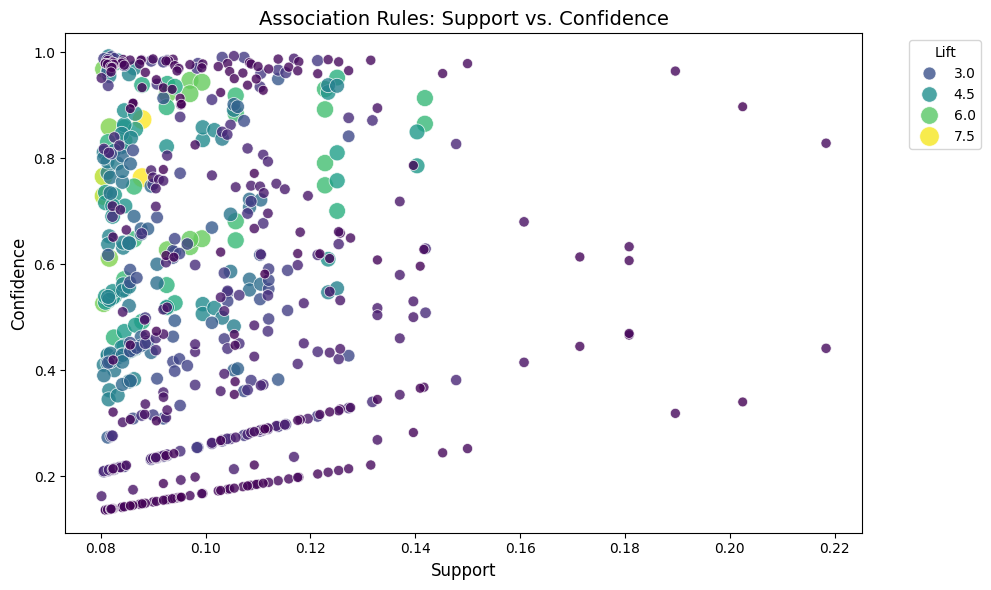

In [14]:
# --- scripts/06_associationgraph.py ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_fil = '../data/04_association.csv'
df_rules = pd.read_csv(input_fil)

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_rules,
    x='support',
    y='confidence',
    hue='lift',
    palette='viridis', 
    size='lift',       
    sizes=(50, 200),
    alpha=0.8
)

plt.title('Association Rules: Support vs. Confidence', fontsize=14)
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lift')
plt.tight_layout()
plt.savefig('scatter_association_rules.png')
plt.show()

# Section 2: Exploratory Data Analysis
### 2.1 Distribution of Ratings
We examine the average rating distribution to establish a baseline. Initial findings suggest that romance readers are generally positive, with a rating density peaking around 4.0.

### 2.2 Engagement Volume & Correlation Analysis
We perform a Pearson correlation analysis across four key metrics: `rating`, `n_votes`, `n_comments`, and `review_length`. 
* **Key Hypothesis:** Does review length or rating sentiment drive community interaction?

### 5. Create Histogram

Loading data from ../data/02_extractedbooks.csv...


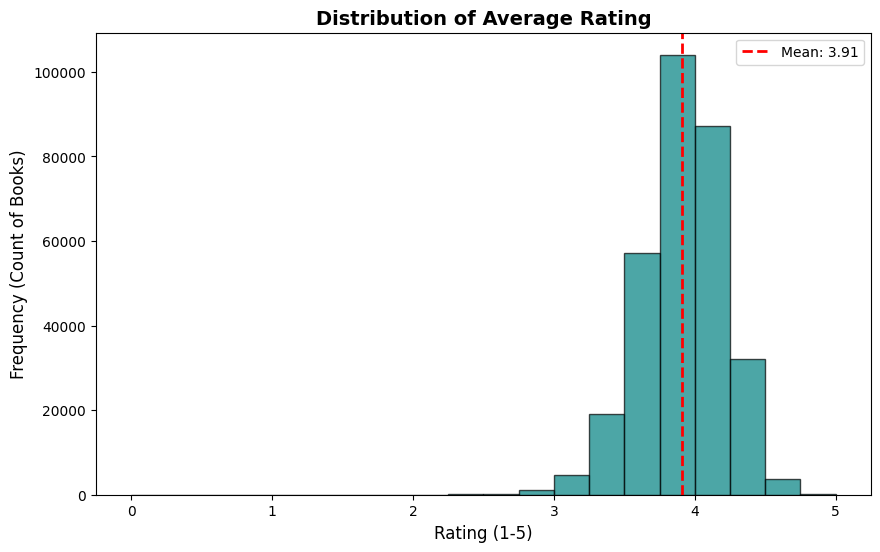

Success! Histogram saved to ../docs/rating_histogram.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import gzip

# --- Configuration ---
# Set these to match your actual file names
INPUT_DATA = '../data/02_extractedbooks.csv'  # The CSV created in the previous step
OUTPUT_PLOT = '../docs/rating_histogram.png'

def generate_histogram(input_path, output_path, column_name='average_rating'):
    """
    Generates a rating distribution histogram from a CSV file.
    """
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} does not exist.")
        return

    print(f"Loading data from {input_path}...")
    df = pd.read_csv(input_path)
    
    # Check if the requested column exists, otherwise look for 'rating'
    if column_name not in df.columns and 'rating' in df.columns:
        column_name = 'rating'
    
    if column_name not in df.columns:
        print(f"Error: Could not find '{column_name}' or 'rating' columns in the dataset.")
        return

    # Set up the visual style
    plt.figure(figsize=(10, 6))
    df[column_name].hist(
        bins=20,
        color="#008080",
        edgecolor='black',
        grid=False,
        alpha=0.7
    )
    
    # Calculate statistics for the legend
    mean_val = df[column_name].mean()
    median_val = df[column_name].median()
    
    # Visual cues
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    # Formatting
    title = column_name.replace('_', ' ').title()
    plt.title(f'Distribution of {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Rating (1-5)', fontsize=12)
    plt.ylabel('Frequency (Count of Books)', fontsize=12)
    plt.legend()

    # Save and show
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Success! Histogram saved to {output_path}")

def generate_histogram_from_json(input_path, output_path, key_name='average_rating'):
    """
    Utility to generate a histogram directly from a JSON or JSON.GZ file 
    (Useful for raw data before it is converted to CSV).
    """
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} not found.")
        return

    data_points = []
    count = 0
    open_func = gzip.open if input_path.endswith('.gz') else open
    
    print(f"Streaming data from {input_path}...")
    with open_func(input_path, 'rt', encoding='utf-8') as fin:
        for line in fin:
            try:
                record = json.loads(line)
                # Fixed the 'avarage' typo from the original script
                value = record.get(key_name)
                if value is not None:
                    data_points.append(float(value))
                
                count += 1
                if count % 100000 == 0:
                    print(f"Processed {count} records...")
            except (json.JSONDecodeError, ValueError):
                continue

    if not data_points:
        print("No valid rating data found.")
        return

    plt.figure(figsize=(10, 6))
    plt.hist(data_points, bins=40, color="#008080", edgecolor='black', alpha=0.7)
    
    plt.title(f'Ratings Distribution (Raw JSON)', fontsize=14, fontweight='bold')
    plt.xlabel(key_name.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
# Use this for the CSV output of your previous scripts
generate_histogram(INPUT_DATA, OUTPUT_PLOT)

# OR: Use this if you want to plot directly from a raw JSON/GZ file
# generate_histogram_from_json('../data/01_filteredbooks.json', '../docs/raw_histogram.png')

### 6. Create Bar Geaph

Reading ../data/01_filteredbooks_noadmin.json to measure tag frequencies...


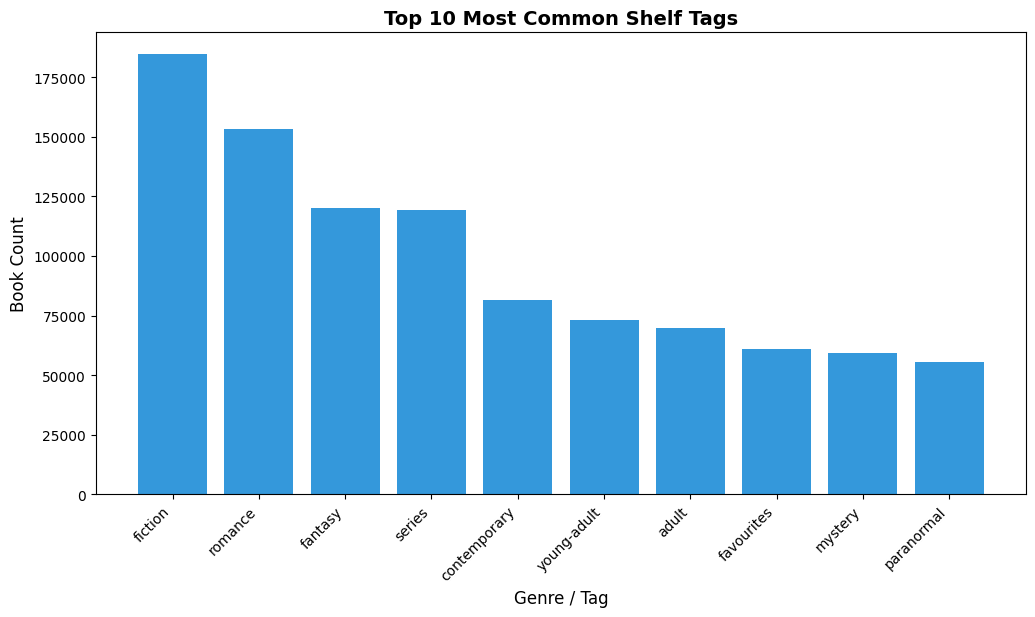


TOP 15 DISCOVERED ATTRIBUTES (SHELF TAGS)
               Tag  Book Count
           fiction      184531
           romance      153342
           fantasy      120119
            series      119359
      contemporary       81648
       young-adult       73231
             adult       69889
        favourites       60888
           mystery       59299
        paranormal       55366
historical-fiction       55333
        historical       51156
   science-fiction       50785
             i-own       50657
            sci-fi       48089
Results saved to ../data/06_tags.csv


In [19]:
import pandas as pd 
import json 
import os
from collections import Counter
import matplotlib.pyplot as plt

# --- Configuration ---
# Update these paths to match your project structure
INPUT_JSON = '../data/01_filteredbooks_noadmin.json'
OUTPUT_CSV = '../data/06_tags.csv'
OUTPUT_PLOT = '../docs/10commonbargraph.png'

def generate_tag_frequency(input_path, csv_path, plot_path, top_n=10):
    """
    Analyzes shelf tag frequency and generates a bar graph of the top genres.
    """
    if not os.path.exists(input_path):
        print(f"Error: Input file {input_path} not found.")
        return

    tags_counts = Counter()
    print(f"Reading {input_path} to measure tag frequencies...")
    
    with open(input_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                book = json.loads(line)
                shelves = book.get('popular_shelves', [])
                tags = []
                for s in shelves:
                    # Robust handling for both dict and string tag formats
                    if isinstance(s, dict):
                        tags.append(s['name'].lower().strip())
                    elif isinstance(s, str):
                        tags.append(s.lower().strip())
                tags_counts.update(tags)
            except json.JSONDecodeError:
                continue
                
    # Create DataFrame of the most common tags
    df = pd.DataFrame(tags_counts.most_common(50), columns=['Tag', 'Book Count'])
    top_tags = df.head(top_n)
    
    # --- Visualization ---
    plt.figure(figsize=(12, 6))
    plt.bar(top_tags['Tag'], top_tags['Book Count'], color='#3498db')
    
    plt.title(f'Top {top_n} Most Common Shelf Tags', fontsize=14, fontweight='bold')
    plt.xlabel('Genre / Tag', fontsize=12)
    plt.ylabel('Book Count', fontsize=12)
    
    # Rotate labels to prevent overlap
    plt.xticks(rotation=45, ha='right')
    
    # Ensure directories exist before saving
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save full frequency list to CSV
    df.to_csv(csv_path, index=False)
    
    print("\n" + "="*45)
    print(f"TOP 15 DISCOVERED ATTRIBUTES (SHELF TAGS)")
    print("="*45)
    print(df.head(15).to_string(index=False))
    print("="*45)
    print(f"Results saved to {csv_path}")

# --- Execution ---
generate_tag_frequency(INPUT_JSON, OUTPUT_CSV, OUTPUT_PLOT, top_n=10)

### 6. Generate Heatmap

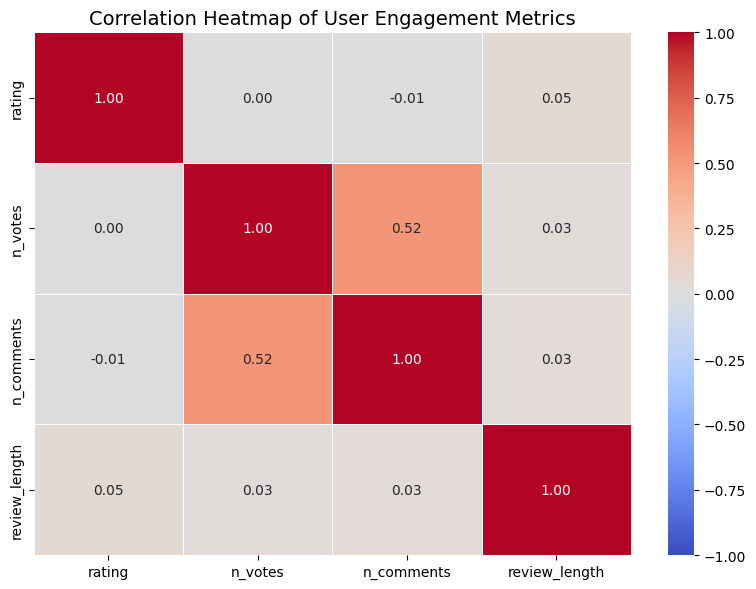

In [10]:
# --- scripts/07_heatmap.py ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_reviews = pd.read_csv('../data/03_extractedreviews.csv')

if 'review_length' not in df_reviews.columns:
    df_reviews['review_length'] = df_reviews['review_snippet'].astype(str).apply(len)

numeric_cols = ['rating', 'n_votes', 'n_comments', 'review_length']
df_numeric = df_reviews[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of User Engagement Metrics', fontsize=14)
plt.tight_layout()

plt.savefig('../docs/correlation_heatmap.png')
plt.show()

### 8. Generate scatterplot

/tmp/ipykernel_23655/2648539853.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


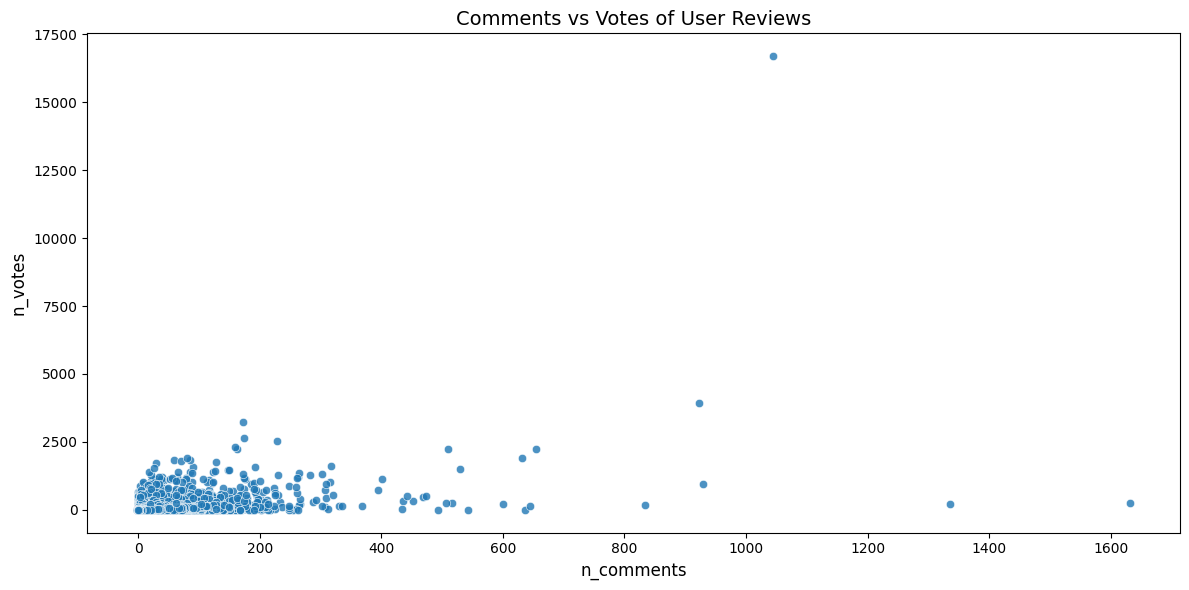

In [11]:
# --- scripts/08_scatterplot.py ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_rules = pd.read_csv('../data/03_extractedreviews.csv')

plt.figure(figsize=(12, 6))

scatter = sns.scatterplot(
    data=df_rules,
    x='n_comments',
    y='n_votes',
    palette='viridis', 
    sizes=(50, 200),
    alpha=0.8
)

plt.title('Comments vs Votes of User Reviews', fontsize=14)
plt.xlabel('n_comments', fontsize=12)
plt.ylabel('n_votes', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/scatterplot_extractedreviews.png')
plt.show()

# Conclusion & Next Steps
Milestone 2 has successfully established the data pipeline and validated genre associations. 

**Upcoming Milestone 3 Plan:**
* **K-Means Clustering:** Segmenting users into "Reader Personas" based on rating variance and review frequency.
* **LDA Topic Modeling:** Extracting qualitative themes from the `review_text` to understand what drives "helpful" votes.